# Transfer_Learning_Vision_Architectures

In [1]:
#!pip install --upgrade pip
#!pip install -q torch torchvision pandas matplotlib scikit-learn seaborn


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


## Dataset Setup
### Using Severstal Defect Dataset

This notebook uses the `Severstal: Steel Defect Detection` dataset with 4 defect types:
- **Scratches**: Surface scratches and abrasions
- **Inclusions**: Foreign particles embedded in steel
- **Patches**: Localized surface irregularities
- **Rolls Marks**: Marks from the rolling process

Directory structure:
```
single_class_sampled/
├── Scratches/
├── Inclusions/
├── Patches/
└── Rolls Marks/
```


In [3]:
# Define path to dataset
dataset_path = r"C:\Users\yuvarajendraan\Documents\MIMER\Training-MS\Data\single_class_sampled"

if not os.path.exists(dataset_path):
    print(f"Error: {dataset_path} folder not found!")
else:
    print(f"Dataset path: {os.path.abspath(dataset_path)}")

Dataset path: C:\Users\yuvarajendraan\Documents\MIMER\Training-MS\Data\single_class_sampled


In [4]:
# Get sorted class names
class_names = sorted(os.listdir(dataset_path))
print(f"Classes found: {class_names}")
print(f"Number of classes: {len(class_names)}")

# Count images per class
for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    num_images = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    print(f"{class_name}: {num_images} images")


Classes found: ['Inclusions', 'Patches', 'Rolls Marks', 'Scratches']
Number of classes: 4
Inclusions: 195 images
Patches: 500 images
Rolls Marks: 500 images
Scratches: 500 images


In [5]:
# Load full dataset
BATCH_SIZE = 32
IMAGE_SIZE = 255

# PyTorch transforms (normalize with ImageNet stats for transfer learning)
base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=dataset_path,
                                    transform=base_transform)

# Extract all images and labels as arrays for splitting
all_indices = list(range(len(full_dataset)))
all_labels  = [full_dataset.targets[i] for i in all_indices]

# First split: 70% train, 30% holdout (val + test)
train_idx, holdout_idx = train_test_split(
    all_indices, test_size=0.3, random_state=0, stratify=all_labels
)

holdout_labels = [all_labels[i] for i in holdout_idx]

# Second split: 15% val, 15% test
val_idx, test_idx = train_test_split(
    holdout_idx, test_size=0.5, random_state=0, stratify=holdout_labels
)

# Subset samplers
from torch.utils.data import Subset
train_dataset = Subset(full_dataset, train_idx)
val_dataset   = Subset(full_dataset, val_idx)
test_dataset  = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Total images:       {len(full_dataset)}")
print(f"Training samples:   {len(train_dataset)} ({len(train_dataset)/len(full_dataset)*100:.1f}%)")
print(f"Validation samples: {len(val_dataset)}   ({len(val_dataset)/len(full_dataset)*100:.1f}%)")
print(f"Test samples:       {len(test_dataset)}   ({len(test_dataset)/len(full_dataset)*100:.1f}%)")


Total images:       1695
Training samples:   1186 (70.0%)
Validation samples: 254   (15.0%)
Test samples:       255   (15.0%)


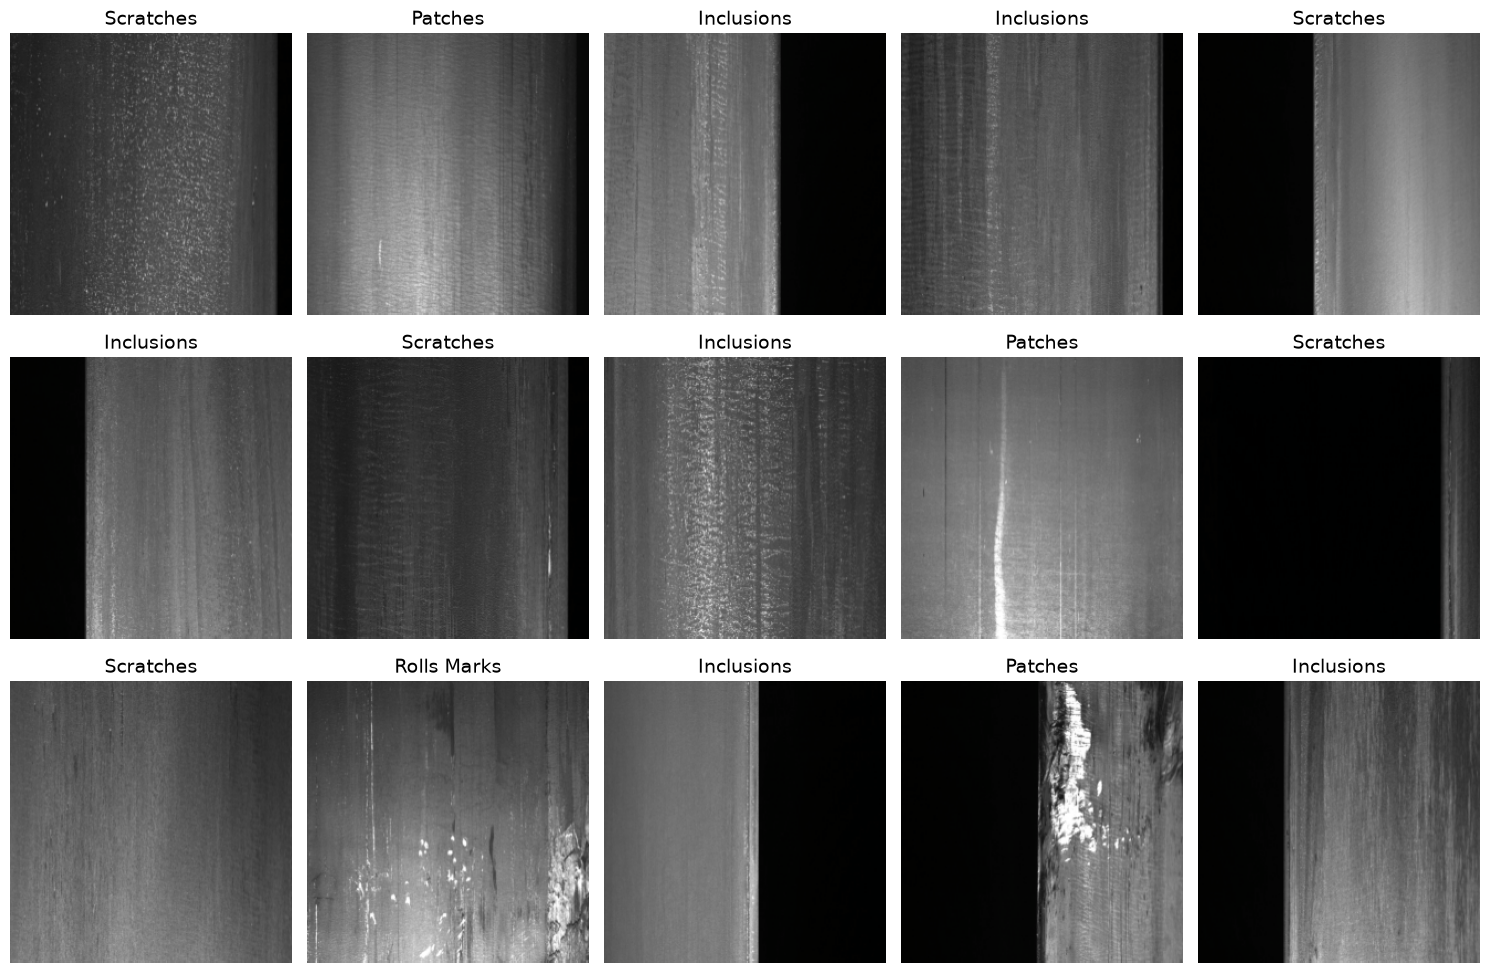

In [6]:
# Visualize sample images from training set
# (un-normalize for display)
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

plt.figure(figsize=(15, 10))
images_batch, labels_batch = next(iter(train_loader))
for i in range(min(15, len(images_batch))):
    ax = plt.subplot(3, 5, i + 1)
    img = inv_normalize(images_batch[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(class_names[labels_batch[i].item()], fontsize=14)
    plt.axis('off')
plt.tight_layout()
plt.show()


## Data Augmentation

In [7]:
# ============================================================
# DATA AUGMENTATION (optional for training split only)
# ============================================================

from torch.utils.data import Subset, ConcatDataset

def augment_dataset(dataset, multiplier):
    """
    Return an augmented version of a dataset Subset.

    Builds an augmented "view" of the same underlying ImageFolder and
    re-points the given subset's indices at it, so the exact same samples
    are used — just transformed on-the-fly. Repeats them `multiplier` times
    so each epoch sees that many freshly-augmented passes.

    NOTE: only call this on the TRAINING split. Augmenting val/test would
    distort evaluation.

    Args:
        dataset:    a torch.utils.data.Subset wrapping an ImageFolder
                    (e.g. train_dataset, val_dataset).
        multiplier: how many augmented passes per epoch (1 = same count).

    Returns:
        ConcatDataset of the augmented subset, repeated `multiplier` times.
    """
    # Augmentations tailored for steel-surface defects: orientation-agnostic
    # flips/rotations, mild geometric jitter, lighting variation.
    # Normalization matches the original base_transform (ImageNet stats).
    augment_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=30),
        transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.25, contrast=0.25),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.20, scale=(0.02, 0.10)),  # occlusion robustness
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    # Recover the original ImageFolder root and this subset's indices
    root = dataset.dataset.root
    indices = dataset.indices

    # Augmented "view" of the same folder, same samples, new transform
    augmented_base = datasets.ImageFolder(root=root, transform=augment_transform)
    augmented_subset = Subset(augmented_base, indices)

    return ConcatDataset([augmented_subset] * multiplier)


# --- Apply augmentation to the training split ----------------


AUG_MULTIPLIER = 4

train_dataset2 = augment_dataset(train_dataset, multiplier=AUG_MULTIPLIER)

# Reassign the training loader (val/test loaders unchanged)
train_loader = DataLoader(train_dataset2, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print(f"Training samples: {len(train_dataset2)} ({AUG_MULTIPLIER}x, on-the-fly augmentation)")
print(f"Validation samples: {len(val_dataset)}  ")
print(f"Test samples:       {len(test_dataset)} ")

Training samples: 4744 (4x, on-the-fly augmentation)
Validation samples: 254  
Test samples:       255 


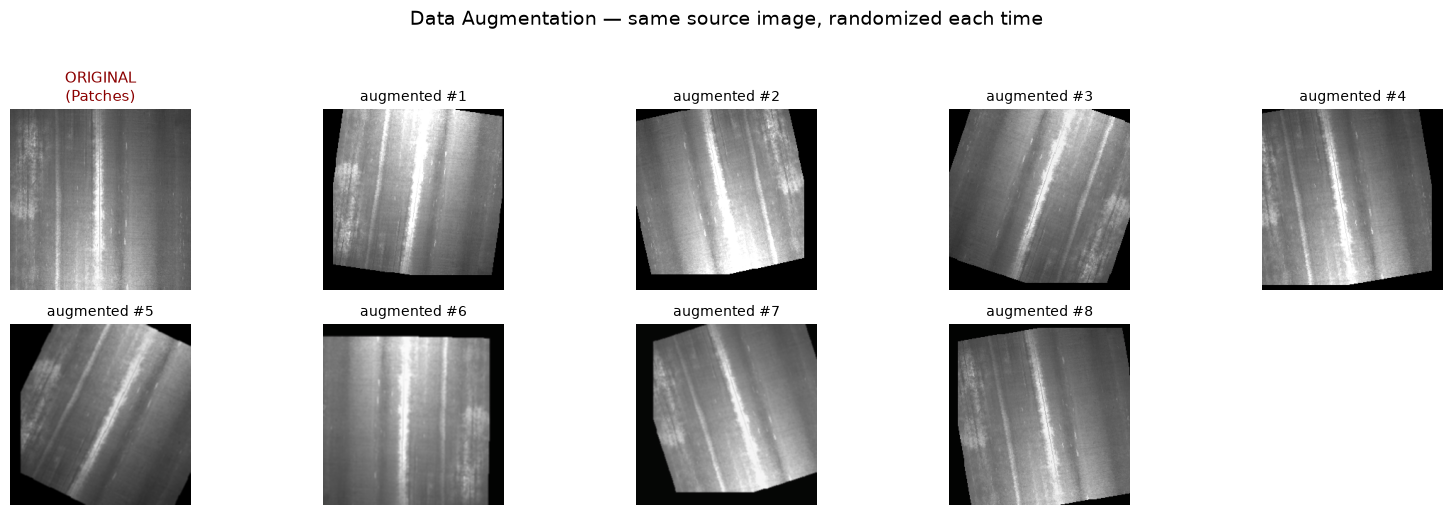

In [8]:
# --- Visualize the augmentations -----------------------------
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

from PIL import Image
import random

# Grab one RANDOM source image + its transform from the augmented training set
aug_subset = train_dataset2.datasets[0]            # the Subset inside ConcatDataset
aug_base = aug_subset.dataset                       # the augmented ImageFolder
sample_idx = random.choice(aug_subset.indices)      # random → different defect each run
src_path, src_label = aug_base.imgs[sample_idx][0], aug_base.targets[sample_idx]
pil_img = Image.open(src_path).convert("RGB")

n_show = 8
plt.figure(figsize=(16, 5))

ax = plt.subplot(2, (n_show // 2) + 1, 1)
plt.imshow(pil_img.resize((IMAGE_SIZE, IMAGE_SIZE)))
plt.title(f"ORIGINAL\n({class_names[src_label]})", fontsize=11, color="darkred")
plt.axis("off")

for i in range(n_show):
    ax = plt.subplot(2, (n_show // 2) + 1, i + 2)
    aug_tensor = aug_base.transform(pil_img)
    img = inv_normalize(aug_tensor).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(f"augmented #{i+1}", fontsize=10)
    plt.axis("off")

plt.suptitle("Data Augmentation — same source image, randomized each time",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Transfer Learning with VGG16

In [9]:
## Transfer Learning with VGG16
def build_vgg16_model(num_classes):
    vgg16_backbone = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    # print(vgg16_backbone.features)
    # print(vgg16_backbone.classifier)

    # Freeze all pretrained layers
    for param in vgg16_backbone.parameters():
        param.requires_grad = False

    # remove last classifier layer
    # in_features = vgg16_backbone.classifier[0].in_features # 25088

    vgg16_backbone.classifier = nn.Sequential(
        *list(vgg16_backbone.classifier.children())[:-1]
    )
    # NOW build your classifier
    in_features = 4096
    
    model = nn.Sequential(
        vgg16_backbone,
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )

    return model

# Build model
model_vgg16 = build_vgg16_model(num_classes=len(class_names)).to(device)

# Model summary
total_params = sum(p.numel() for p in model_vgg16.parameters())
trainable_params = sum(p.numel() for p in model_vgg16.parameters() if p.requires_grad)

print("VGG16 Transfer Learning Model")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")


VGG16 Transfer Learning Model
Total parameters:     136,490,564
Trainable parameters: 2,230,020
Frozen parameters:    134,260,544


In [10]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs, model_name="Model"):
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # ---- Validation ----
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc   = val_correct / val_total

        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}]  "
              f"loss: {train_loss:.4f}  acc: {train_acc:.4f}  "
              f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}")

    print("\nTraining completed!")
    return history

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer_vgg16 = optim.Adam(model_vgg16.parameters(), lr=0.001)
EPOCHS = 6

start = time.time()
print("Training VGG16 Transfer Learning Model...")
history_vgg16 = train_model(
    model_vgg16,
    train_loader,
    val_loader,
    optimizer_vgg16,
    criterion,
    EPOCHS,
    "VGG16"
)
print("Time:", time.time() - start, "sec")
time_vgg16 = time.time() - start

Training VGG16 Transfer Learning Model...
Epoch [1/6]  loss: 1.0627  acc: 0.5048  val_loss: 0.8718  val_acc: 0.6024
Epoch [2/6]  loss: 0.9717  acc: 0.5656  val_loss: 0.7962  val_acc: 0.6693
Epoch [3/6]  loss: 0.9213  acc: 0.5877  val_loss: 0.8362  val_acc: 0.6654
Epoch [4/6]  loss: 0.9145  acc: 0.5993  val_loss: 0.7494  val_acc: 0.6811
Epoch [5/6]  loss: 0.9000  acc: 0.5913  val_loss: 0.7009  val_acc: 0.7283
Epoch [6/6]  loss: 0.8830  acc: 0.6060  val_loss: 0.6727  val_acc: 0.7283

Training completed!
Time: 524.1951172351837 sec


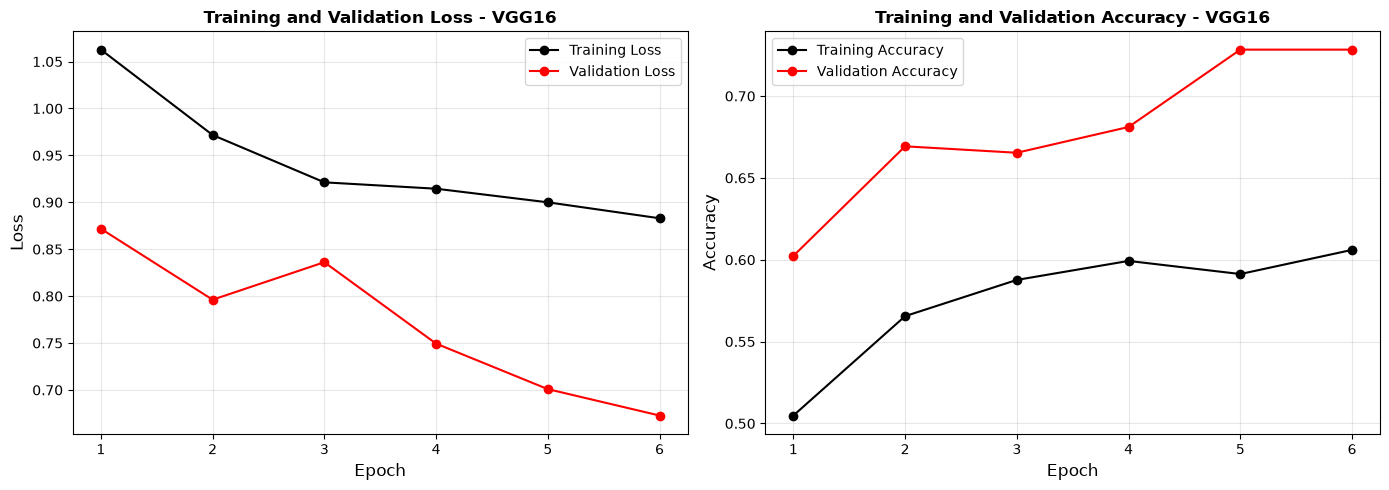

In [12]:
# Plot Training History for VGG16
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.arange(1, EPOCHS + 1), history_vgg16['loss'],
             color='black', label='Training Loss', marker='o')
axes[0].plot(np.arange(1, EPOCHS + 1), history_vgg16['val_loss'],
             color='red', label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss - VGG16', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(1, EPOCHS + 1), history_vgg16['accuracy'],
             color='black', label='Training Accuracy', marker='o')
axes[1].plot(np.arange(1, EPOCHS + 1), history_vgg16['val_accuracy'],
             color='red', label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy - VGG16', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


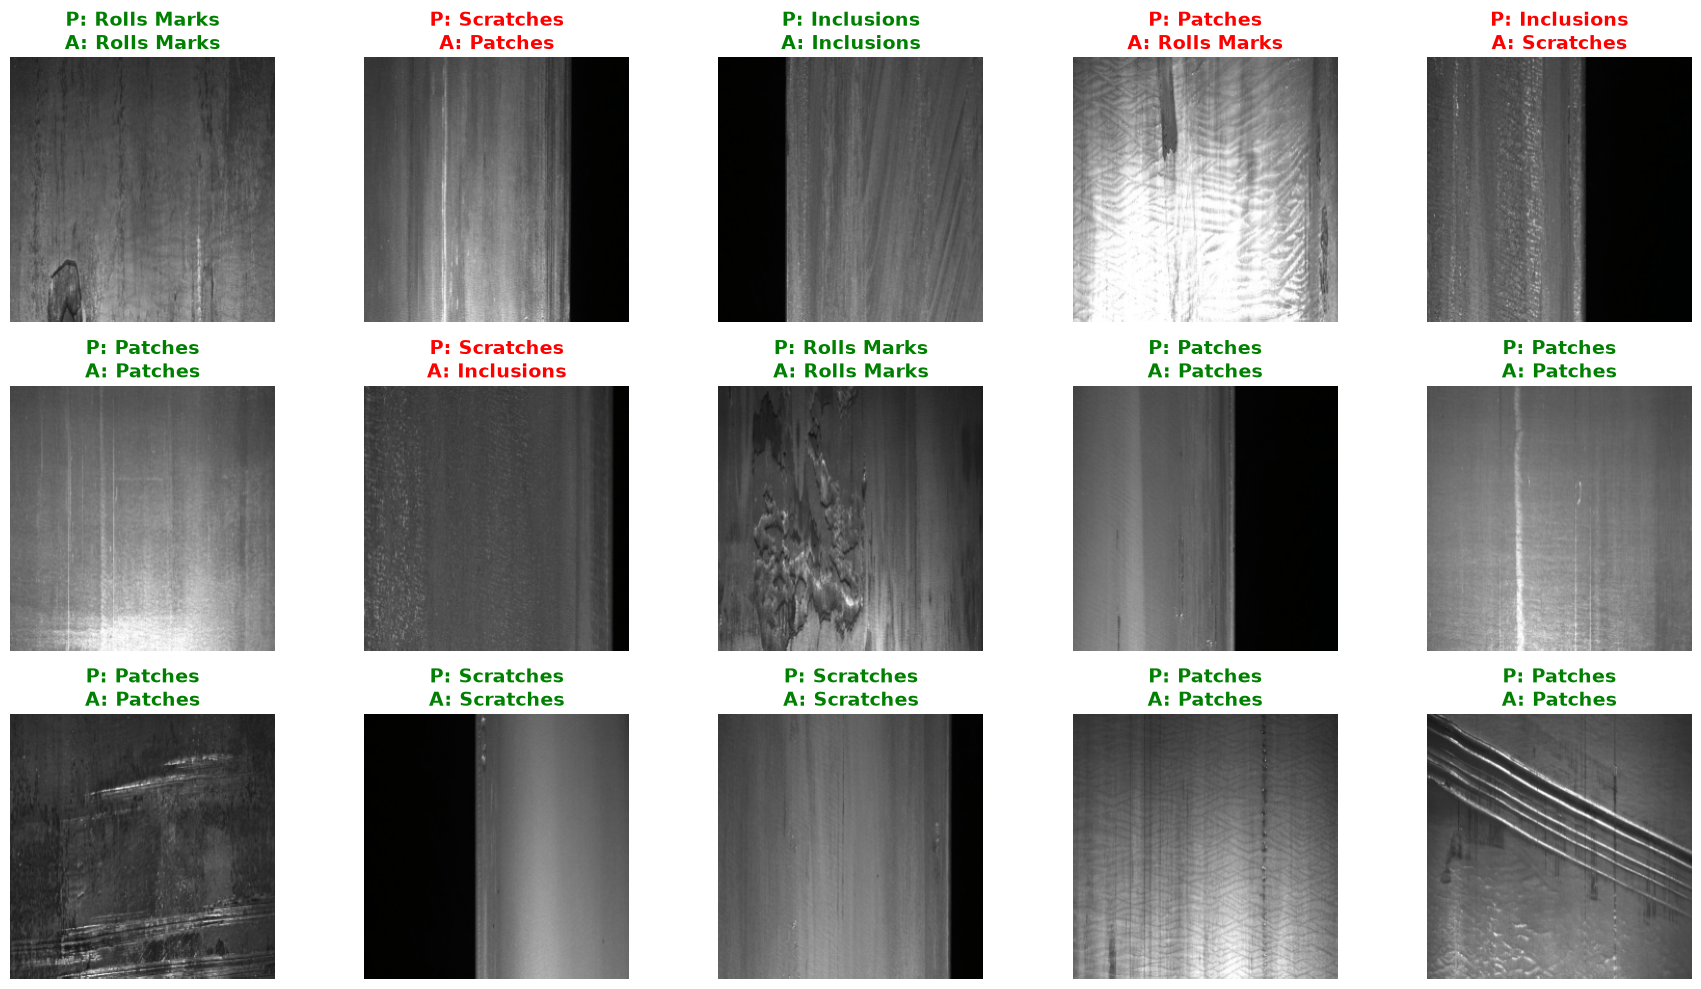

In [13]:
# Visualize Predictions on Test Set - VGG16
model_vgg16.eval()
plt.figure(figsize=(18, 10))

images_batch, labels_batch = next(iter(test_loader))
images_batch_dev = images_batch.to(device)

with torch.no_grad():
    outputs = model_vgg16(images_batch_dev)
    _, predicted_classes = torch.max(outputs, 1)

for i in range(min(15, len(images_batch))):
    ax = plt.subplot(3, 5, i + 1)
    img = inv_normalize(images_batch[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)

    actual_class_idx = labels_batch[i].item()
    actual_class     = class_names[actual_class_idx]
    predicted_class  = class_names[predicted_classes[i].item()]

    color = 'green' if actual_class_idx == predicted_classes[i].item() else 'red'
    plt.title(f"P: {predicted_class}\nA: {actual_class}",
              color=color, fontweight='bold', fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()


Computing predictions on test set...
Test Accuracy: 0.7216 (72.16%)


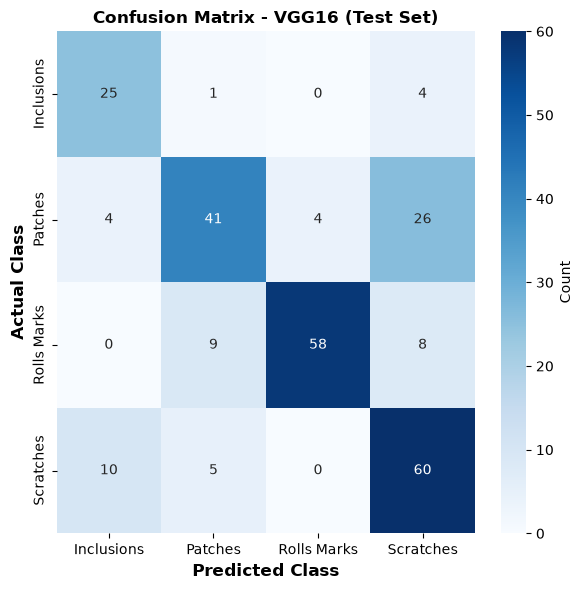


CLASSIFICATION REPORT - VGG16 (Test Set)
              precision    recall  f1-score   support

  Inclusions     0.6410    0.8333    0.7246        30
     Patches     0.7321    0.5467    0.6260        75
 Rolls Marks     0.9355    0.7733    0.8467        75
   Scratches     0.6122    0.8000    0.6936        75

    accuracy                         0.7216       255
   macro avg     0.7302    0.7383    0.7227       255
weighted avg     0.7460    0.7216    0.7224       255



In [14]:
# Confusion Matrix and Classification Report - VGG16 (Test)
print("Computing predictions on test set...")
model_vgg16.eval()
ypred_test, ylabel_test = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_vgg16(images)
        _, predicted = torch.max(outputs, 1)
        ypred_test.extend(predicted.cpu().numpy())
        ylabel_test.extend(labels.numpy())

cm_test = confusion_matrix(ylabel_test, ypred_test)
test_accuracy = np.sum(np.array(ypred_test) == np.array(ylabel_test)) / len(ylabel_test)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_test, annot=True, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            fmt='d', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - VGG16 (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CLASSIFICATION REPORT - VGG16 (Test Set)")
print("="*60)
print(classification_report(ylabel_test, ypred_test,
                             labels=list(range(len(class_names))),
                             target_names=class_names, digits=4))
print("="*60)


In [15]:
# Save VGG16 Model
torch.save(model_vgg16.state_dict(), 'model_vgg16_model.pth')
print("VGG16 model saved as 'model_vgg16_model.pth'")


VGG16 model saved as 'model_vgg16_model.pth'


## Fine-tuning VGG16 - Unfreezing the last Conv block (block5) 

## Fine-Tuning: Unfreezing the Last Conv Block

So far the entire VGG16 backbone was frozen and only the new classifier head was trained (~2.23M parameters). We now **unfreeze the last convolutional block (block5)** so its filters can adapt from generic ImageNet features to the specific textures and patterns of steel-surface defects.

This raises the trainable parameter count to roughly **9.3M**, since block5's three convolutional layers add about 7M trainable weights on top of the head.

**Why this can affect results:**
- **Upside** — the deepest conv features become specialized to our defect classes, which can improve accuracy when the target domain differs from ImageNet.
- **Risk** — more trainable parameters on a small dataset (~1,186 unique images) increases the chance of **overfitting**. To mitigate this, we keep the early blocks frozen (their edge/texture features generalize well) and fine-tune the backbone with a **much lower learning rate** than the head, so the pretrained weights are nudged rather than overwritten.

In [16]:
## Transfer Learning with VGG16 - last conv block (block5) unfrozen for fine-tuning 
def build_vgg16_model_ft(num_classes):
    vgg16_backbone_ft = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

    # Freeze all pretrained layers
    for param in vgg16_backbone_ft.parameters():
        param.requires_grad = False

    # remove last classifier layer
    vgg16_backbone_ft.classifier = nn.Sequential(
        *list(vgg16_backbone_ft.classifier.children())[:-1]
    )
    in_features = 4096

    model = nn.Sequential(
        vgg16_backbone_ft,
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model


def unfreeze_vgg16_block5(model):
    """
    Unfreeze VGG16's last conv block (block5) for fine-tuning.

    VGG16's `features` is a Sequential of 31 layers; block5 is the final
    conv block, spanning index 24 to the end (3 conv layers + ReLUs + pool).
    Everything before stays frozen so the generic early features are preserved.
    """
    vgg16_backbone_ft = model[0]          # the VGG16 module inside the outer Sequential
    features = vgg16_backbone_ft.features

    # Unfreeze from layer index 24 onward (block5)
    for idx, layer in enumerate(features):
        for param in layer.parameters():
            param.requires_grad = (idx >= 24)

    return model


# Build model
model_vgg16_ft = build_vgg16_model_ft(num_classes=len(class_names)).to(device)

# Unfreeze the last conv block for fine-tuning
model_vgg16_ft = unfreeze_vgg16_block5(model_vgg16_ft)

# --- Discriminative learning rates -----------------------------
# Backbone (unfrozen block5) trains slowly to preserve pretrained features;
# the new classifier head trains faster.
backbone_params = [p for p in model_vgg16_ft[0].parameters() if p.requires_grad]
head_params     = [p for layer in list(model_vgg16_ft)[1:] for p in layer.parameters()]

optimizer_vgg16_ft = optim.Adam([
    {"params": backbone_params, "lr": 1e-5},   # fine-tune slowly
    {"params": head_params,     "lr": 1e-4},   # train head faster
])

# Model summary
total_params     = sum(p.numel() for p in model_vgg16_ft.parameters())
trainable_params = sum(p.numel() for p in model_vgg16_ft.parameters() if p.requires_grad)

print("VGG16 Fine-Tuning Model (block5 unfrozen)")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")

VGG16 Fine-Tuning Model (block5 unfrozen)
Total parameters:     136,490,564
Trainable parameters: 9,309,444
Frozen parameters:    127,181,120


In [17]:
# Training the fine-tuned VGG16 model - last conv block (block5) unfrozen for fine-tuning
criterion = nn.CrossEntropyLoss()
optimizer_vgg16_ft = optim.Adam(model_vgg16_ft.parameters(), lr=0.001)
EPOCHS = 6

start = time.time()
print("Training VGG16 Transfer Learning Model...")
history_vgg16_ft = train_model(
    model_vgg16_ft,
    train_loader,
    val_loader,
    optimizer_vgg16_ft,
    criterion,
    EPOCHS,
    "VGG16"
)
print("Time:", time.time() - start, "sec")
time_vgg16_ft = time.time() - start

Training VGG16 Transfer Learning Model...
Epoch [1/6]  loss: 0.9343  acc: 0.5824  val_loss: 0.6033  val_acc: 0.7402
Epoch [2/6]  loss: 0.6326  acc: 0.7523  val_loss: 0.4838  val_acc: 0.8386
Epoch [3/6]  loss: 0.5492  acc: 0.7981  val_loss: 0.5141  val_acc: 0.7638
Epoch [4/6]  loss: 0.4776  acc: 0.8276  val_loss: 0.4929  val_acc: 0.8228
Epoch [5/6]  loss: 0.4747  acc: 0.8316  val_loss: 0.4664  val_acc: 0.8307
Epoch [6/6]  loss: 0.4456  acc: 0.8379  val_loss: 0.4321  val_acc: 0.8465

Training completed!
Time: 554.3836605548859 sec


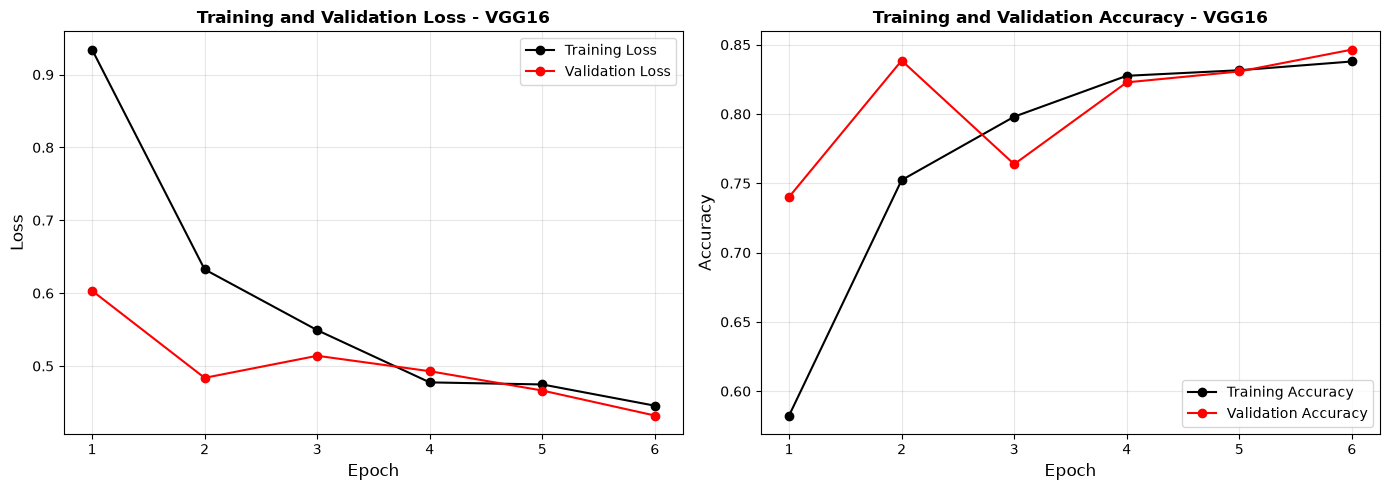

In [18]:
# Plot Training History for VGG16 - last conv block (block5) unfrozen for fine-tuning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.arange(1, EPOCHS + 1), history_vgg16_ft['loss'],
             color='black', label='Training Loss', marker='o')
axes[0].plot(np.arange(1, EPOCHS + 1), history_vgg16_ft['val_loss'],
             color='red', label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss - VGG16', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(1, EPOCHS + 1), history_vgg16_ft['accuracy'],
             color='black', label='Training Accuracy', marker='o')
axes[1].plot(np.arange(1, EPOCHS + 1), history_vgg16_ft['val_accuracy'],
             color='red', label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy - VGG16', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


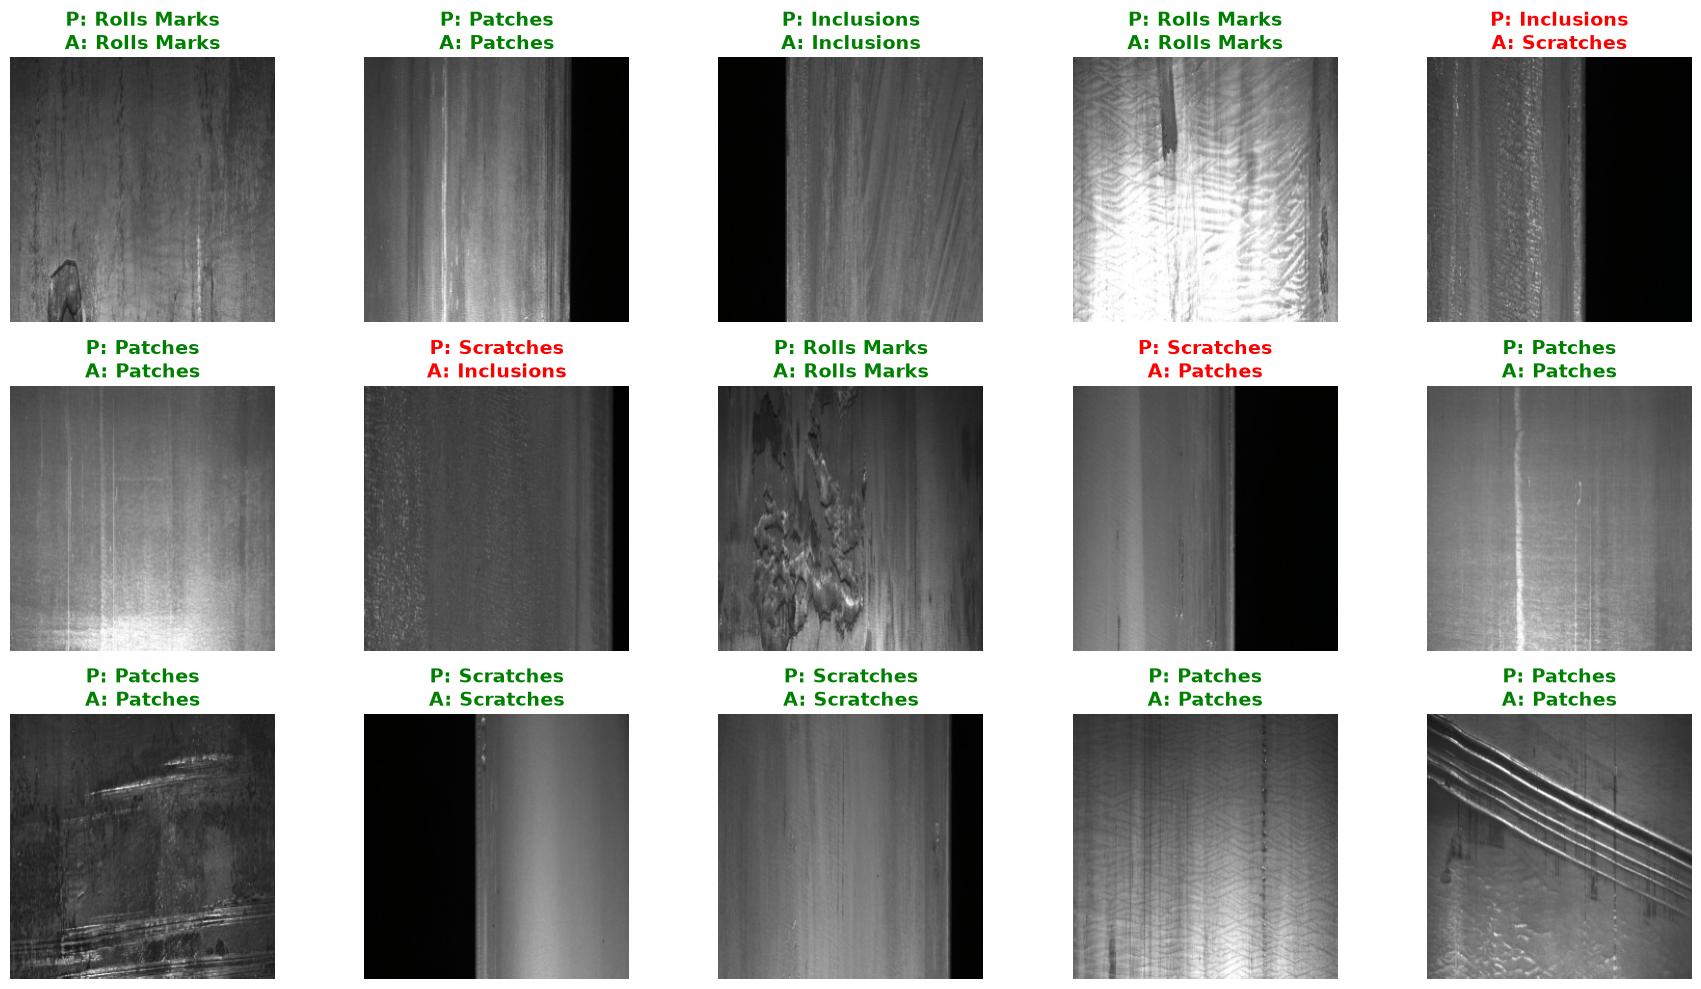

In [19]:
# Visualize Predictions on Test Set - VGG16 - last conv block (block5) unfrozen for fine-tuning
model_vgg16.eval()
plt.figure(figsize=(18, 10))

images_batch, labels_batch = next(iter(test_loader))
images_batch_dev = images_batch.to(device)

with torch.no_grad():
    outputs = model_vgg16_ft(images_batch_dev)
    _, predicted_classes = torch.max(outputs, 1)

for i in range(min(15, len(images_batch))):
    ax = plt.subplot(3, 5, i + 1)
    img = inv_normalize(images_batch[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)

    actual_class_idx = labels_batch[i].item()
    actual_class     = class_names[actual_class_idx]
    predicted_class  = class_names[predicted_classes[i].item()]

    color = 'green' if actual_class_idx == predicted_classes[i].item() else 'red'
    plt.title(f"P: {predicted_class}\nA: {actual_class}",
              color=color, fontweight='bold', fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()


Computing predictions on test set...
Test Accuracy: 0.8235 (82.35%)


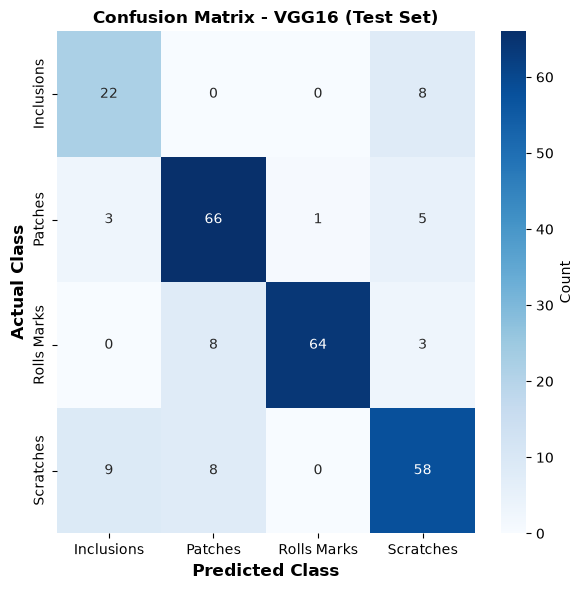


CLASSIFICATION REPORT - VGG16 (Test Set)
              precision    recall  f1-score   support

  Inclusions     0.6471    0.7333    0.6875        30
     Patches     0.8049    0.8800    0.8408        75
 Rolls Marks     0.9846    0.8533    0.9143        75
   Scratches     0.7838    0.7733    0.7785        75

    accuracy                         0.8235       255
   macro avg     0.8051    0.8100    0.8053       255
weighted avg     0.8330    0.8235    0.8261       255



In [20]:
# Confusion Matrix and Classification Report - VGG16 (Test) - last conv block (block5) unfrozen for fine-tuning
print("Computing predictions on test set...")
model_vgg16_ft.eval()
ypred_test, ylabel_test = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_vgg16_ft(images)
        _, predicted = torch.max(outputs, 1)
        ypred_test.extend(predicted.cpu().numpy())
        ylabel_test.extend(labels.numpy())

cm_test = confusion_matrix(ylabel_test, ypred_test)
test_accuracy = np.sum(np.array(ypred_test) == np.array(ylabel_test)) / len(ylabel_test)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_test, annot=True, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            fmt='d', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - VGG16 (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CLASSIFICATION REPORT - VGG16 (Test Set)")
print("="*60)
print(classification_report(ylabel_test, ypred_test,
                             labels=list(range(len(class_names))),
                             target_names=class_names, digits=4))
print("="*60)


## Assignment: Transfer Learning with MobileNetV2

MobileNetV2 (Google, 2018) is a lightweight CNN designed for speed and efficiency on mobile and edge devices. Its key trick is the **depthwise separable convolution** — splitting a normal convolution into a cheap per-channel spatial filter followed by a 1×1 channel-mixing step — combined with **inverted residual blocks** that expand, filter, then compress the channels, with skip connections between the narrow ends.

The result is a model with only **~3.4M parameters** (vs. VGG16's ~138M) that still reaches solid ImageNet accuracy. This efficiency makes it a strong transfer-learning choice for our small dataset: fewer parameters mean faster training and less risk of overfitting.
Apply transfer learning using MobileNetV2 to build an image classification model for Steel Defect Detection dataset.
You are required to:
Load a pretrained MobileNetV2 model from torchvision. Inspect the model architecture and explore its parameters and layers.
Freeze the pretrained feature extractor layers.
Replace the classifier with a custom neural network head.
Train the model on your dataset.
Evaluate performance on validation data.
Compare results with previous VGG16 model.

## Solution

In [21]:
# Load pre-trained MobileNetV2 base model
base_model_mbv2 = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Freeze base model weights
for param in base_model_mbv2.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in base_model_mbv2.parameters())
print(f"Base model loaded with {total_params:,} parameters")
print(f"Trainable params (frozen): {sum(p.numel() for p in base_model_mbv2.parameters() if p.requires_grad):,}")


Base model loaded with 3,504,872 parameters
Trainable params (frozen): 0


In [22]:
# Build Transfer Learning Model with MobileNetV2
def build_mobilenetv2_model():
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    # Freeze all base layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace the classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, len(class_names))
    )
    return model

model_mbv2 = build_mobilenetv2_model().to(device)

trainable = sum(p.numel() for p in model_mbv2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_mbv2.parameters())
print(f"\nMobileNetV2 Transfer Learning Model")
print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")



MobileNetV2 Transfer Learning Model
Total parameters:     2,552,836
Trainable parameters: 328,964


In [23]:
# Train MobileNetV2 Model
EPOCHS = 6
start = time.time()
optimizer_mbv2 = optim.Adam(model_mbv2.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
print("Training MobileNetV2 Transfer Learning Model...")
history_mbv2 = train_model(model_mbv2, train_loader, val_loader,
                            optimizer_mbv2, criterion, EPOCHS, "MobileNetV2")
print("Time:", time.time() - start, "sec")
time_mbv2 = time.time() - start

Training MobileNetV2 Transfer Learning Model...
Epoch [1/6]  loss: 0.9692  acc: 0.5670  val_loss: 0.7538  val_acc: 0.6850
Epoch [2/6]  loss: 0.7949  acc: 0.6636  val_loss: 0.6604  val_acc: 0.7362
Epoch [3/6]  loss: 0.7701  acc: 0.6771  val_loss: 0.6137  val_acc: 0.7756
Epoch [4/6]  loss: 0.7393  acc: 0.6937  val_loss: 0.6371  val_acc: 0.7283
Epoch [5/6]  loss: 0.7229  acc: 0.7011  val_loss: 0.6113  val_acc: 0.7520
Epoch [6/6]  loss: 0.7156  acc: 0.7017  val_loss: 0.6092  val_acc: 0.7323

Training completed!
Time: 416.5341866016388 sec


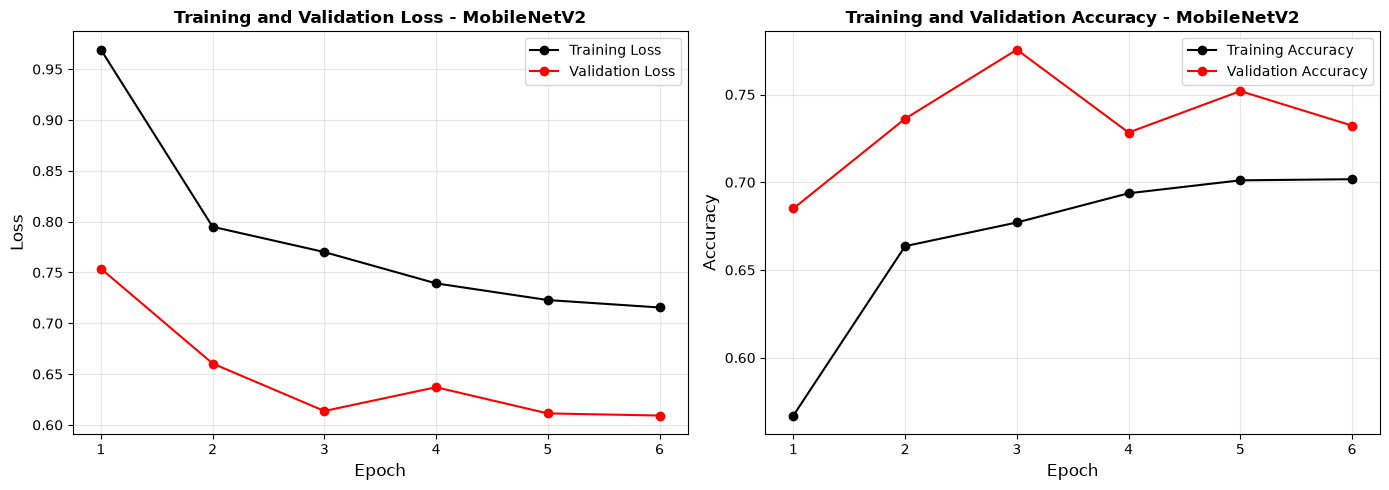

In [24]:
# Plot Training History for MobileNetV2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.arange(1, EPOCHS + 1), history_mbv2['loss'],
             color='black', label='Training Loss', marker='o')
axes[0].plot(np.arange(1, EPOCHS + 1), history_mbv2['val_loss'],
             color='red', label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss - MobileNetV2', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(1, EPOCHS + 1), history_mbv2['accuracy'],
             color='black', label='Training Accuracy', marker='o')
axes[1].plot(np.arange(1, EPOCHS + 1), history_mbv2['val_accuracy'],
             color='red', label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy - MobileNetV2', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


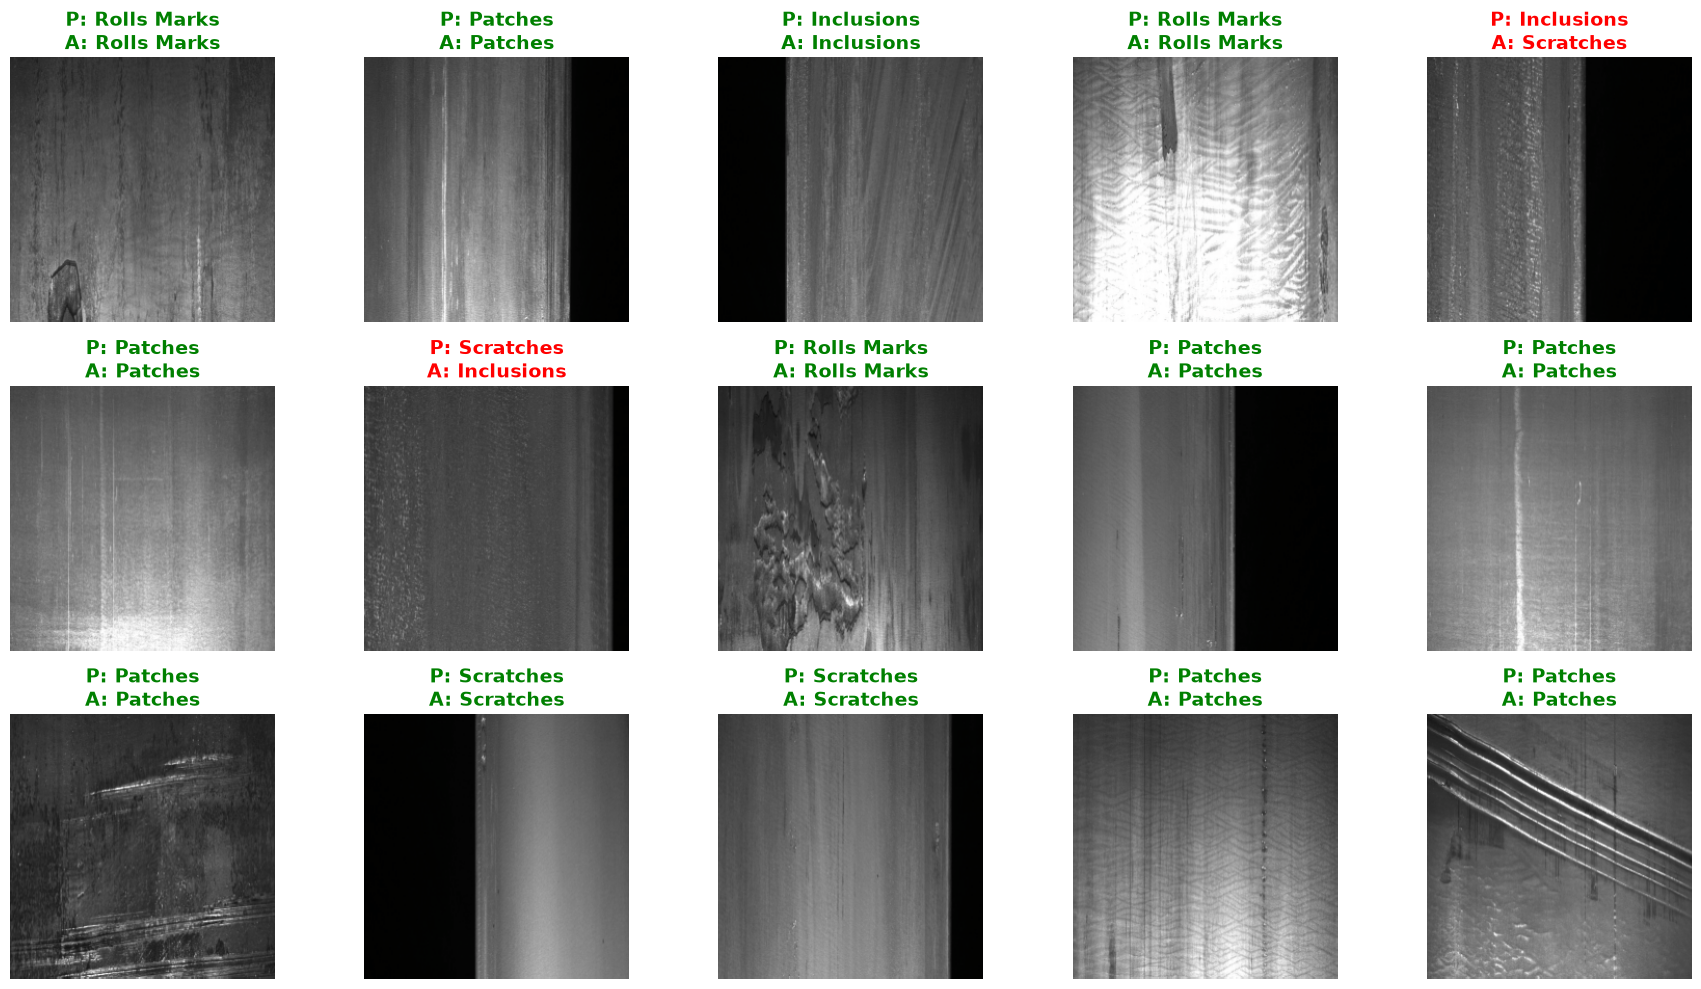

In [25]:
# Visualize Predictions on Test Set - MobileNetV2
model_mbv2.eval()
plt.figure(figsize=(18, 10))

images_batch, labels_batch = next(iter(test_loader))
images_batch_dev = images_batch.to(device)

with torch.no_grad():
    outputs = model_mbv2(images_batch_dev)
    _, predicted_classes = torch.max(outputs, 1)

for i in range(min(15, len(images_batch))):
    ax = plt.subplot(3, 5, i + 1)
    img = inv_normalize(images_batch[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)

    actual_class_idx = labels_batch[i].item()
    actual_class     = class_names[actual_class_idx]
    predicted_class  = class_names[predicted_classes[i].item()]

    color = 'green' if actual_class_idx == predicted_classes[i].item() else 'red'
    plt.title(f"P: {predicted_class}\nA: {actual_class}",
              color=color, fontweight='bold', fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()


Computing predictions on test set...
Test Accuracy: 0.7647 (76.47%)


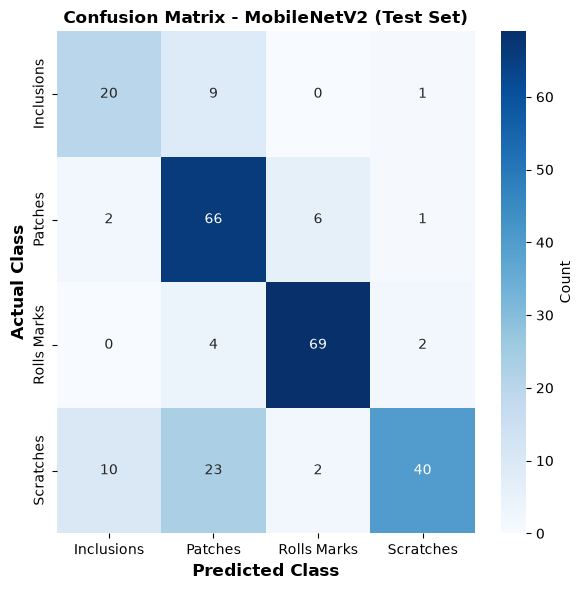


CLASSIFICATION REPORT - MobileNetV2 (Test Set)
              precision    recall  f1-score   support

  Inclusions     0.6250    0.6667    0.6452        30
     Patches     0.6471    0.8800    0.7458        75
 Rolls Marks     0.8961    0.9200    0.9079        75
   Scratches     0.9091    0.5333    0.6723        75

    accuracy                         0.7647       255
   macro avg     0.7693    0.7500    0.7428       255
weighted avg     0.7948    0.7647    0.7600       255



In [26]:
# Confusion Matrix and Classification Report - MobileNetV2 (Test)
print("Computing predictions on test set...")
model_mbv2.eval()
ypred_test, ylabel_test = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_mbv2(images)
        _, predicted = torch.max(outputs, 1)
        ypred_test.extend(predicted.cpu().numpy())
        ylabel_test.extend(labels.numpy())

cm_test = confusion_matrix(ylabel_test, ypred_test)
test_accuracy = np.sum(np.array(ypred_test) == np.array(ylabel_test)) / len(ylabel_test)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_test, annot=True, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            fmt='d', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - MobileNetV2 (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CLASSIFICATION REPORT - MobileNetV2 (Test Set)")
print("="*60)
print(classification_report(ylabel_test, ypred_test,
                             labels=list(range(len(class_names))),
                             target_names=class_names, digits=4))
print("="*60)


In [27]:
# Save MobileNetV2 Model
torch.save(model_mbv2.state_dict(), 'mobilenetv2_model.pth')
print("MobileNetV2 model saved as 'mobilenetv2_model.pth'")

MobileNetV2 model saved as 'mobilenetv2_model.pth'


## Transfer Learning with ResNet50

In [28]:
# Load pre-trained ResNet50 base model with IMAGENET1K_V2 weights
base_model_resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

for param in base_model_resnet.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in base_model_resnet.parameters())
print(f"ResNet50 loaded with {total_params:,} parameters")


ResNet50 loaded with 25,557,032 parameters


In [29]:
# Build ResNet50 Transfer Learning Model
def build_resnet50_model():
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    # Freeze all base layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace the final fully-connected layer
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, len(class_names))
    )
    return model

model_resnet = build_resnet50_model().to(device)

trainable = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_resnet.parameters())
print(f"\nResNet50 Transfer Learning Model")
print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")



ResNet50 Transfer Learning Model
Total parameters:     24,033,604
Trainable parameters: 525,572


In [30]:
# Train ResNet50 Model
criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(model_resnet.fc.parameters(), lr=0.001)
EPOCHS = 6

start = time.time()

print("Training ResNet50 Transfer Learning Model...")
history_resnet = train_model(model_resnet, train_loader, val_loader,
                              optimizer_resnet, criterion, EPOCHS, "ResNet50")
print("Time:", time.time() - start, "sec")
time_resnet = time.time() - start

Training ResNet50 Transfer Learning Model...
Epoch [1/6]  loss: 0.9468  acc: 0.5816  val_loss: 0.7037  val_acc: 0.7126
Epoch [2/6]  loss: 0.7529  acc: 0.6836  val_loss: 0.6146  val_acc: 0.7835
Epoch [3/6]  loss: 0.7215  acc: 0.7015  val_loss: 0.5833  val_acc: 0.7795
Epoch [4/6]  loss: 0.6813  acc: 0.7163  val_loss: 0.5572  val_acc: 0.7835
Epoch [5/6]  loss: 0.6863  acc: 0.7201  val_loss: 0.6119  val_acc: 0.7559
Epoch [6/6]  loss: 0.6763  acc: 0.7249  val_loss: 0.5467  val_acc: 0.7795

Training completed!
Time: 476.2667911052704 sec


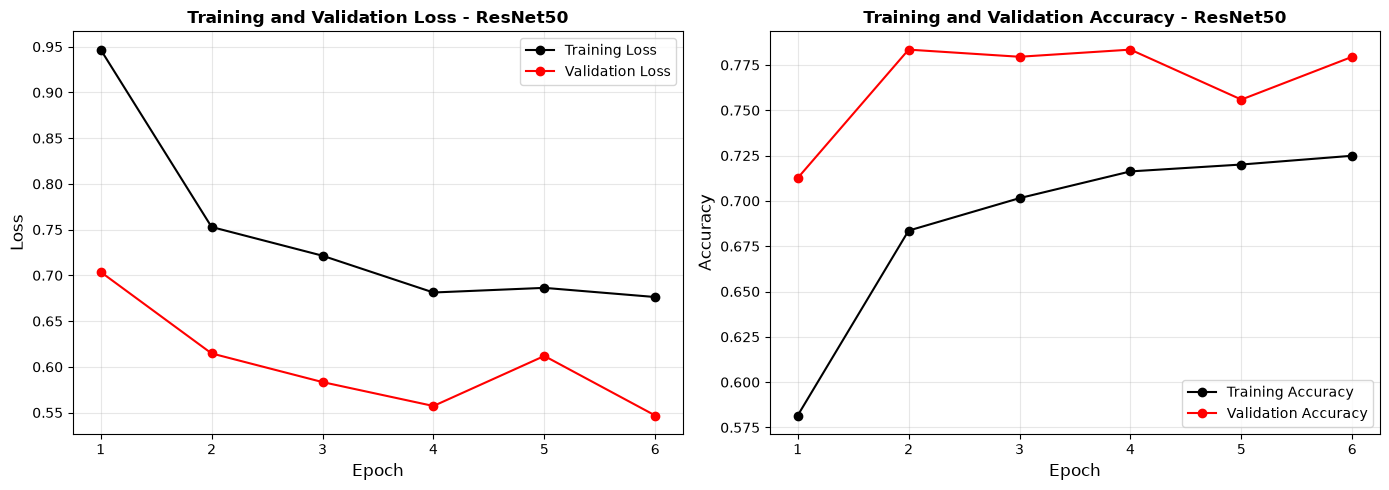

In [31]:
# Plot Training History for ResNet50
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.arange(1, EPOCHS + 1), history_resnet['loss'],
             color='black', label='Training Loss', marker='o')
axes[0].plot(np.arange(1, EPOCHS + 1), history_resnet['val_loss'],
             color='red', label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss - ResNet50', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(1, EPOCHS + 1), history_resnet['accuracy'],
             color='black', label='Training Accuracy', marker='o')
axes[1].plot(np.arange(1, EPOCHS + 1), history_resnet['val_accuracy'],
             color='red', label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy - ResNet50', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Computing predictions on test set...
Test Accuracy: 0.7725 (77.25%)


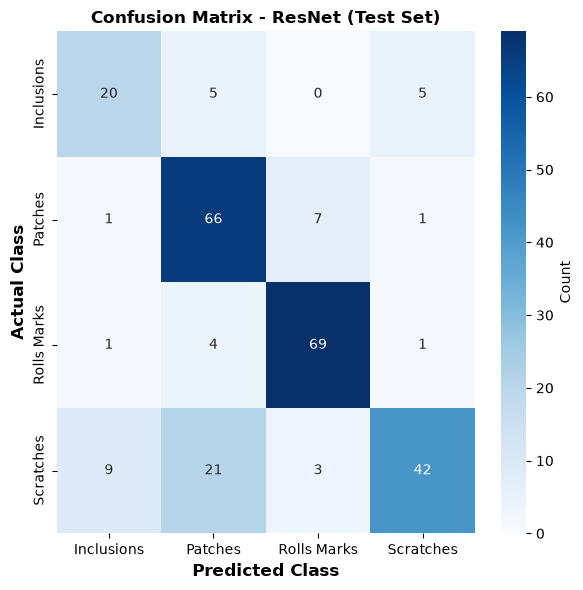


CLASSIFICATION REPORT - ResNet(Test Set)
              precision    recall  f1-score   support

  Inclusions     0.6452    0.6667    0.6557        30
     Patches     0.6875    0.8800    0.7719        75
 Rolls Marks     0.8734    0.9200    0.8961        75
   Scratches     0.8571    0.5600    0.6774        75

    accuracy                         0.7725       255
   macro avg     0.7658    0.7567    0.7503       255
weighted avg     0.7871    0.7725    0.7670       255



In [32]:
# Confusion Matrix and Classification Report - ResNet50 (Test)
print("Computing predictions on test set...")
model_resnet.eval()
ypred_test, ylabel_test = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_resnet(images)
        _, predicted = torch.max(outputs, 1)
        ypred_test.extend(predicted.cpu().numpy())
        ylabel_test.extend(labels.numpy())

cm_test = confusion_matrix(ylabel_test, ypred_test)
test_accuracy = np.sum(np.array(ypred_test) == np.array(ylabel_test)) / len(ylabel_test)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_test, annot=True, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            fmt='d', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - ResNet (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CLASSIFICATION REPORT - ResNet(Test Set)")
print("="*60)
print(classification_report(ylabel_test, ypred_test,
                             labels=list(range(len(class_names))),
                             target_names=class_names, digits=4))
print("="*60)

In [33]:
# Save ResNet50 Model
torch.save(model_resnet.state_dict(), 'resnet50_model.pth')
print("ResNet50 model saved as 'resnet50_model.pth'")


ResNet50 model saved as 'resnet50_model.pth'


### Assignment: Compare transfer Learning with VGG16, MobileNetV2 and ResNet50
Evaluate performance on validation data and test data for all three models (VGG16, MobileNetV2, ResNet50). 
Analyze confusion matrices and classification reports to identify strengths and weaknesses of each model.

A compact comparison:

|              | VGG16              | ResNet50                  | MobileNetV2                       | 
|--------------|--------------------|---------------------------|-----------------------------------|
| Year         | 2014               | 2015                      | 2018                              | 
| Key idea     | Stacked 3×3 convs  | Residual/skip connections | Depthwise separable + inverted residuals | 
| Parameters   | ~138M              | ~25M                      | ~3.4M                             | 
| Depth        | 16 layers          | 50 layers                 | 53 layers                         | 
| Designed for | Accuracy, simplicity | Trainable very deep nets | Mobile/edge efficiency            |
| Trade-off    | Heavy, slow        | Balanced                  | Lightest, slight accuracy cost    | 

# Vision Transformer (ViT) for Defect Classification

Vision Transformers use self-attention mechanisms instead of convolutions, allowing the model to capture global spatial relationships in images.


In [34]:
# Load pre-trained Vision Transformer (ViT-B/16) with ImageNet weights
base_model_vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

for param in base_model_vit.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in base_model_vit.parameters())
print(f"ViT-B/16 loaded with {total_params:,} parameters")

ViT-B/16 loaded with 86,567,656 parameters


In [35]:
# Build ViT Transfer Learning Model
class ViTTransfer(nn.Module):
    """Pretrained ViT-B/16 with a frozen backbone and a new classifier head.

    torchvision's ViT-B/16 expects 224x224 input, but our pipeline uses
    IMAGE_SIZE=255, so we resize inside forward() to keep the data pipeline
    untouched and consistent with the other models.
    """
    def __init__(self, num_classes):
        super().__init__()
        self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

        # Freeze all pretrained layers
        for param in self.vit.parameters():
            param.requires_grad = False

        # ViT's classifier lives in `heads.head`; replace it
        in_features = self.vit.heads.head.in_features   # 768 for ViT-B/16
        self.vit.heads.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Resize 255 -> 224 to match ViT's fixed patch/positional embeddings
        x = F.interpolate(x, size=224, mode="bilinear", align_corners=False)
        return self.vit(x)


def build_vit_model():
    return ViTTransfer(num_classes=len(class_names))

model_vit = build_vit_model().to(device)

trainable = sum(p.numel() for p in model_vit.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_vit.parameters())
print(f"\nViT Transfer Learning Model")
print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")


ViT Transfer Learning Model
Total parameters:     85,996,548
Trainable parameters: 197,892


In [36]:
# Train ViT Model
criterion = nn.CrossEntropyLoss()
# Only the new head params require grad, so pass those to the optimizer
optimizer_vit_tl = optim.Adam(
    [p for p in model_vit.parameters() if p.requires_grad], lr=0.001
)
EPOCHS = 6

start = time.time()

print("Training ViT Transfer Learning Model...")
history_vit_tl = train_model(model_vit, train_loader, val_loader,
                             optimizer_vit_tl, criterion, EPOCHS, "ViT")
print("Time:", time.time() - start, "sec")
time_vit_tl = time.time() - start

Training ViT Transfer Learning Model...
Epoch [1/6]  loss: 0.6948  acc: 0.7083  val_loss: 0.5142  val_acc: 0.7953
Epoch [2/6]  loss: 0.5063  acc: 0.7901  val_loss: 0.4869  val_acc: 0.8110
Epoch [3/6]  loss: 0.4587  acc: 0.8145  val_loss: 0.4487  val_acc: 0.8386
Epoch [4/6]  loss: 0.4142  acc: 0.8375  val_loss: 0.4630  val_acc: 0.8110
Epoch [5/6]  loss: 0.4044  acc: 0.8453  val_loss: 0.4446  val_acc: 0.8307
Epoch [6/6]  loss: 0.3784  acc: 0.8550  val_loss: 0.3778  val_acc: 0.8425

Training completed!
Time: 883.4367537498474 sec


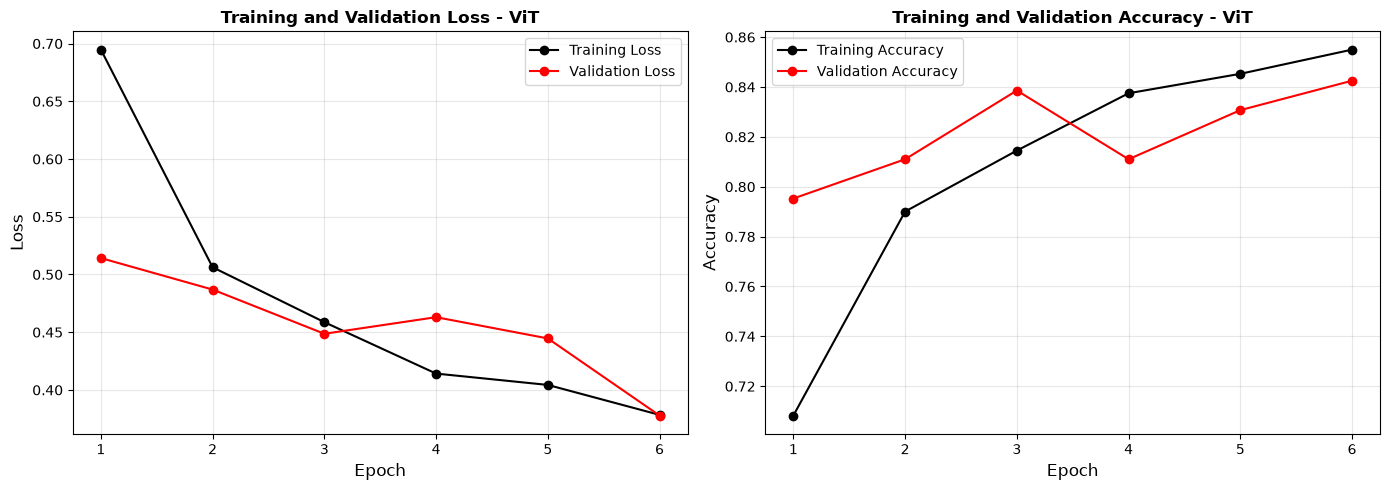

In [37]:
# Plot Training History for ViT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.arange(1, EPOCHS + 1), history_vit_tl['loss'],
             color='black', label='Training Loss', marker='o')
axes[0].plot(np.arange(1, EPOCHS + 1), history_vit_tl['val_loss'],
             color='red', label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss - ViT', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(1, EPOCHS + 1), history_vit_tl['accuracy'],
             color='black', label='Training Accuracy', marker='o')
axes[1].plot(np.arange(1, EPOCHS + 1), history_vit_tl['val_accuracy'],
             color='red', label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy - ViT', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Computing predictions on test set...
Test Accuracy: 0.8392 (83.92%)


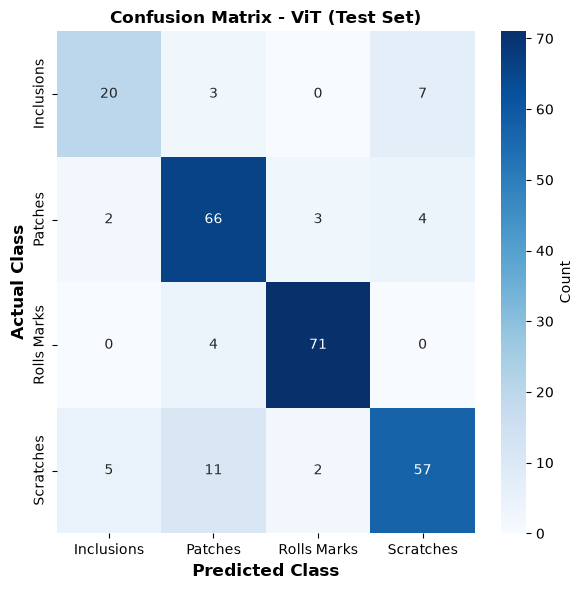


CLASSIFICATION REPORT - ViT (Test Set)
              precision    recall  f1-score   support

  Inclusions     0.7407    0.6667    0.7018        30
     Patches     0.7857    0.8800    0.8302        75
 Rolls Marks     0.9342    0.9467    0.9404        75
   Scratches     0.8382    0.7600    0.7972        75

    accuracy                         0.8392       255
   macro avg     0.8247    0.8133    0.8174       255
weighted avg     0.8395    0.8392    0.8378       255



In [38]:
# Confusion Matrix and Classification Report - ViT (Test)
print("Computing predictions on test set...")
model_vit.eval()
ypred_test, ylabel_test = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_vit(images)
        _, predicted = torch.max(outputs, 1)
        ypred_test.extend(predicted.cpu().numpy())
        ylabel_test.extend(labels.numpy())

cm_test = confusion_matrix(ylabel_test, ypred_test)
test_accuracy = np.sum(np.array(ypred_test) == np.array(ylabel_test)) / len(ylabel_test)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_test, annot=True, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            fmt='d', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - ViT (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CLASSIFICATION REPORT - ViT (Test Set)")
print("="*60)
print(classification_report(ylabel_test, ypred_test,
                             labels=list(range(len(class_names))),
                             target_names=class_names, digits=4))
print("="*60)

In [39]:
# Save ViT Model
torch.save(model_vit.state_dict(), 'vit_transfer_model.pth')
print("ViT transfer learning model saved as 'vit_transfer_model.pth'")

ViT transfer learning model saved as 'vit_transfer_model.pth'


In [40]:
# ============================================================
# GRAND COMPARISON OF ALL TESTED MODELS
# ============================================================
from sklearn.metrics import f1_score, precision_score, recall_score

# --- Register every trained model with its training history and training time ---
# (history is None for any model where you didn't keep the dict)
model_registry = {
    "VGG16 (frozen)":      {"model": model_vgg16,    "history": history_vgg16,    "time": time_vgg16},
    "VGG16 (fine-tuned)":  {"model": model_vgg16_ft, "history": history_vgg16_ft, "time": time_vgg16_ft},
    "MobileNetV2":         {"model": model_mbv2,     "history": history_mbv2,     "time": time_mbv2},
    "ResNet50":            {"model": model_resnet,   "history": history_resnet,   "time": time_resnet},
    "ViT-B/16":            {"model": model_vit,      "history": history_vit_tl,   "time": time_vit_tl},
}

@torch.no_grad()
def evaluate_on_test(model):
    """Return (accuracy, macro_f1, macro_precision, macro_recall, n_params)."""
    model.eval()
    y_pred, y_true = [], []
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.numpy())
    y_pred, y_true = np.array(y_pred), np.array(y_true)
    acc  = (y_pred == y_true).mean()
    f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    n_params = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return acc, f1, prec, rec, n_params, n_trainable

# --- Build the comparison table ---
rows = []
for name, entry in model_registry.items():
    acc, f1, prec, rec, n_params, n_train = evaluate_on_test(entry["model"])
    hist = entry["history"]
    rows.append({
        "Model": name,
        "Test Accuracy": acc,
        "F1-score": f1,
        "Precision": prec,
        "Recall": rec,
        "Best Val Acc": max(hist["val_accuracy"]) if hist else np.nan,
        "Final Train Acc": hist["accuracy"][-1] if hist else np.nan,
        "Epochs": len(hist["loss"]) if hist else np.nan,
        "Params (M)": n_params / 1e6,
        "Trainable (M)": n_train / 1e6,
        "Training Time (s)": entry["time"],
    })

results_df = pd.DataFrame(rows).reset_index(drop=True)

print("=" * 80)
print("GRAND MODEL COMPARISON  (Test Set)")
print("=" * 80)
with pd.option_context("display.float_format", lambda x: f"{x:.4f}"):
    print(results_df.to_string(index=False))
print("=" * 80)
best_idx = results_df["Test Accuracy"].idxmax()
print(f"Best model: {results_df.iloc[best_idx]['Model']} "
      f"({results_df.iloc[best_idx]['Test Accuracy']*100:.2f}% test accuracy)")

GRAND MODEL COMPARISON  (Test Set)
             Model  Test Accuracy  F1-score  Precision  Recall  Best Val Acc  Final Train Acc  Epochs  Params (M)  Trainable (M)  Training Time (s)
    VGG16 (frozen)         0.7216    0.7227     0.7302  0.7383        0.7283           0.6060       6    136.4906         2.2300           524.1971
VGG16 (fine-tuned)         0.8235    0.8053     0.8051  0.8100        0.8465           0.8379       6    136.4906         9.3094           554.3837
       MobileNetV2         0.7647    0.7428     0.7693  0.7500        0.7756           0.7017       6      2.5528         0.3290           416.5342
          ResNet50         0.7725    0.7503     0.7658  0.7567        0.7835           0.7249       6     24.0336         0.5256           476.2668
          ViT-B/16         0.8392    0.8174     0.8247  0.8133        0.8425           0.8550       6     85.9965         0.1979           883.4368
Best model: ViT-B/16 (83.92% test accuracy)


A compact comparison:

|              | VGG16              | ResNet50                  | MobileNetV2                       | Vision Transformer (ViT-B/16)        |
|--------------|--------------------|---------------------------|-----------------------------------|--------------------------------------|
| Year         | 2014               | 2015                      | 2018                              | 2020                                 |
| Key idea     | Stacked 3×3 convs  | Residual/skip connections | Depthwise separable + inverted residuals | Self-attention over image patches |
| Parameters   | ~138M              | ~25M                      | ~3.4M                             | ~86M                                 |
| Depth        | 16 layers          | 50 layers                 | 53 layers                         | 12 transformer blocks                |
| Designed for | Accuracy, simplicity | Trainable very deep nets | Mobile/edge efficiency            | Global context, scale with big data  |
| Trade-off    | Heavy, slow        | Balanced                  | Lightest, slight accuracy cost    | Data-hungry; needs large pre-training |